# Assignment 3 — PTB-XL CNN-Enhanced GNN Pipeline

Full pipeline for the PTB-XL dataset (Assignment 3 additional dataset requirement):
1. Mount Drive & install
2. Download PTB-XL records (100 records for compatibility test)
3. Config & imports
4. SCP code → superclass mapping
5. Signal → image (128×128 waveform PNGs)
6. Edge transform (Prewitt, resize to 64×64)
7. CNN encoder definition (PatchCNNEncoder)
8. Graph construction with 32-dim CNN node features
9. Build DataFrames & save TU-format files to Drive
10. Load datasets, train CNNGraphGNNModel, evaluate

**Run cells top to bottom. Do not skip cells.**


## Cell 1 — Mount Drive & Install

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys
!{sys.executable} -m pip install torch_geometric wfdb -q
print("Ready.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready.


## Cell 2 — Download PTB-XL Records

Downloads the CSV metadata and first 100 ECG records (LR = 100 Hz versions,
smaller files). Change `MAX_RECORDS` in Cell 3 Config to match.


In [17]:
import wfdb
import pandas as pd
import os

PTBXL_DIR   = 'ptb-xl/'
MAX_DL      = 100   # must match MAX_RECORDS in Cell 3

# Step 1: CSV files
wfdb.dl_files('ptb-xl', dl_dir=PTBXL_DIR, files=[
    'ptbxl_database.csv',
    'scp_statements.csv',
])

# Step 2: Read first MAX_DL record paths from CSV
df_meta = pd.read_csv(PTBXL_DIR + 'ptbxl_database.csv', index_col='ecg_id')
df_meta = df_meta.head(MAX_DL)

# Step 3: Download .dat + .hea pairs
files_to_dl = []
for rel_path in df_meta['filename_lr']:
    files_to_dl.append(rel_path + '.dat')
    files_to_dl.append(rel_path + '.hea')

wfdb.dl_files('ptb-xl', dl_dir=PTBXL_DIR, files=files_to_dl)
print(f"Downloaded {len(df_meta)} records ({len(files_to_dl)} files).")


Finished downloading files
Finished downloading files
Downloaded 100 records (200 files).


## Cell 3 — Imports & Config

In [18]:
import os, ast, time, json, gc, os.path as osp
import numpy as np
import pandas as pd
import cv2
import wfdb
import tqdm
import glob
import matplotlib
matplotlib.use('Agg')   # headless — required for buffer_rgba() to work
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch_geometric.nn as pyg_nn
from torch_geometric.nn import GraphConv, GCNConv, GATConv, GATv2Conv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch_geometric.data import InMemoryDataset
from torch_geometric.io import read_tu_data
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# ── PATHS & DATASET CONFIG ────────────────────────────────────────────────────
PTBXL_DIR    = 'ptb-xl/'
IMG_DIR      = 'processed_data/images/'
EDGE_DIR     = 'processed_data/edge_filtered/'
DATA_ROOT    = '/content/drive/MyDrive/processed_data'   # Drive output root
TRAIN_NAME   = 'Trainset_PTBXL_CNN'
TEST_NAME    = 'Testset_PTBXL_CNN'

# ── PIPELINE CONFIG ───────────────────────────────────────────────────────────
IMG_SIZE     = (128, 128)   # waveform PNG size (Prewitt will resize to 64x64)
LEAD_INDEX   = 1            # Lead II (index 1 in PTB-XL 12-lead array)
MAX_RECORDS  = 100          # records to use (keep small for compatibility test)
CNN_FEAT_DIM = 32           # output dim of PatchCNNEncoder
PATCH_SIZE   = 7            # local patch extracted around each bright pixel

# ── TRAINING CONFIG ───────────────────────────────────────────────────────────
EPOCHS         = 10
BATCH_SIZE     = 64
LR             = 0.001
WEIGHT_DECAY   = 2e-5
STEP_SIZE      = 20
LAYER_NAME     = 'GraphConv'   # 'GraphConv' | 'GCN' | 'GAT' | 'GATv2'
C_HIDDEN       = 64
NUM_LAYERS     = 3
DP_RATE        = 0.5
DP_RATE_LINEAR = 0.5
PATIENCE       = 10
SEED           = 42
NUM_WORKERS    = 0   # 0 = safest on Colab

# ── LABEL MAPPINGS ────────────────────────────────────────────────────────────
labels_to_float = '{ "NORM":"0","MI":"1","STTC":"2","CD":"3","HYP":"4" }'
float_to_labels = '{ "0":"NORM","1":"MI","2":"STTC","3":"CD","4":"HYP" }'
labels        = json.loads(labels_to_float)
revert_labels = json.loads(float_to_labels)
num_classes   = len(revert_labels)
# ─────────────────────────────────────────────────────────────────────────────

import random
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device  : {device}")
print(f"Classes : {list(revert_labels.values())}")
print(f"Records : {MAX_RECORDS}  |  IMG: {IMG_SIZE}  |  CNN dim: {CNN_FEAT_DIM}")


Device  : cpu
Classes : ['NORM', 'MI', 'STTC', 'CD', 'HYP']
Records : 100  |  IMG: (128, 128)  |  CNN dim: 32


## Cell 4 — SCP Code → Superclass Mapping

PTB-XL stores diagnostic codes in `scp_codes` (e.g. `{'NORM': 100.0}`).
We map these to 5 superclasses using `scp_statements.csv`.
The dominant superclass (highest likelihood) is used as the record label.

**This cell fixes the NORM-only bug** — without it, records with MI/STTC/CD/HYP
codes would be skipped because they weren't in a simple lookup dict.


In [19]:
scp_df = pd.read_csv(PTBXL_DIR + 'scp_statements.csv', index_col=0)
# Keep only diagnostic codes
scp_df = scp_df[scp_df['diagnostic'] == 1]

# Build fine-grained code → superclass map
subclass_to_superclass = {}
for code, row in scp_df.iterrows():
    sc = row.get('diagnostic_class', None)
    if pd.notna(sc) and sc in ['NORM', 'MI', 'STTC', 'CD', 'HYP']:
        subclass_to_superclass[code] = sc

print(f"SCP mappings loaded: {len(subclass_to_superclass)} codes")
print("Sample:", dict(list(subclass_to_superclass.items())[:5]))

def get_superclass(scp_codes_str):
    """Parse scp_codes string, return dominant superclass or None."""
    try:
        codes = ast.literal_eval(scp_codes_str)
    except Exception:
        return None
    found = {}
    for code, likelihood in codes.items():
        sc = subclass_to_superclass.get(code)
        if sc is not None:
            # keep highest-likelihood entry per superclass
            if sc not in found or likelihood > found[sc]:
                found[sc] = likelihood
    # Priority order: pick first superclass that appears
    for sc in ['NORM', 'MI', 'STTC', 'CD', 'HYP']:
        if sc in found:
            return sc
    return None

# Quick test
df_test = pd.read_csv(PTBXL_DIR + 'ptbxl_database.csv', index_col='ecg_id').head(5)
for ecg_id, row in df_test.iterrows():
    sc = get_superclass(row['scp_codes'])
    print(f"  ecg_id {ecg_id}: {row['scp_codes'][:60]}... → {sc}")


SCP mappings loaded: 44 codes
Sample: {'NDT': 'STTC', 'NST_': 'STTC', 'DIG': 'STTC', 'LNGQT': 'STTC', 'NORM': 'NORM'}
  ecg_id 1: {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}... → NORM
  ecg_id 2: {'NORM': 80.0, 'SBRAD': 0.0}... → NORM
  ecg_id 3: {'NORM': 100.0, 'SR': 0.0}... → NORM
  ecg_id 4: {'NORM': 100.0, 'SR': 0.0}... → NORM
  ecg_id 5: {'NORM': 100.0, 'SR': 0.0}... → NORM


## Cell 5 — Signal → Image

Reads each PTB-XL record, extracts Lead II, plots the full 10-second waveform
as a 128×128 grayscale PNG (white line on black background).

Output: `processed_data/images/{NORM,MI,STTC,CD,HYP}/`


In [20]:
def signal_to_image(signal, size):
    """Plot a 1D signal, capture as grayscale image, return as uint8 numpy array."""
    fig = plt.figure(frameon=False)
    plt.plot(np.arange(len(signal)), signal)
    plt.xticks([]); plt.yticks([])
    for spine in plt.gca().spines.values():
        spine.set_visible(False)
    fig.canvas.draw()
    # Capture RGBA buffer from Agg backend
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    buf = buf.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    plt.cla(); plt.clf(); plt.close('all')
    im_gray = cv2.cvtColor(buf, cv2.COLOR_RGBA2GRAY)
    im_gray = cv2.resize(im_gray, size, interpolation=cv2.INTER_LANCZOS4)
    im_gray = np.invert(im_gray)   # white waveform on black background
    return im_gray


os.makedirs(IMG_DIR, exist_ok=True)
df_meta = pd.read_csv(PTBXL_DIR + 'ptbxl_database.csv',
                      index_col='ecg_id').head(MAX_RECORDS)

saved, skipped = 0, 0
for ecg_id, row in tqdm.tqdm(df_meta.iterrows(), total=len(df_meta),
                              desc='sig_to_img'):
    label = get_superclass(row['scp_codes'])
    if label is None:
        skipped += 1
        continue
    full_path = os.path.join(PTBXL_DIR, row['filename_lr'])
    try:
        sig, _ = wfdb.rdsamp(full_path)
    except Exception as e:
        print(f"  WARNING: could not read {full_path}: {e}")
        skipped += 1
        continue
    lead_ii  = sig[:, LEAD_INDEX].astype(np.float32)
    im_gray  = signal_to_image(lead_ii, IMG_SIZE)
    out_dir  = os.path.join(IMG_DIR, label)
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, f'{label}_{ecg_id:05d}.png')
    cv2.imwrite(out_path, im_gray)
    saved += 1

print(f"\nSaved: {saved}  Skipped: {skipped}")
print("Class breakdown:")
for cls in ['NORM', 'MI', 'STTC', 'CD', 'HYP']:
    path = os.path.join(IMG_DIR, cls)
    n    = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f"  {cls}: {n} images")


sig_to_img: 100%|██████████| 100/100 [00:04<00:00, 24.01it/s]


Saved: 95  Skipped: 5
Class breakdown:
  NORM: 76 images
  MI: 5 images
  STTC: 6 images
  CD: 6 images
  HYP: 2 images


## Cell 6 — Edge Transform (Prewitt, resize to 64×64)

Applies Prewitt edge detection to each waveform image and resizes to 64×64.

**Why 64×64?** At 128×128 each image produces ~4000+ nodes.
With 100 records this is manageable but 64×64 (~500–1000 nodes) is faster
for the compatibility test. Consistent with the MIT-BIH pipeline.

Output: `processed_data/edge_filtered/{NORM,MI,STTC,CD,HYP}/`


In [21]:
EDGE_OUT_SIZE = 64   # final size after Prewitt

def prewitt_filter(filepath):
    """Apply Prewitt edge detection, return 64x64 uint8 edge image."""
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (EDGE_OUT_SIZE, EDGE_OUT_SIZE))
    kernel_h = np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=np.float32)
    kernel_v = kernel_h.T
    h_grad   = cv2.filter2D(img, -1, kernel_h)
    v_grad   = cv2.filter2D(img, -1, kernel_v)
    mag      = np.sqrt(h_grad**2 + v_grad**2).astype(np.float32)
    mag      = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    return mag.astype(np.uint8)


os.makedirs(EDGE_DIR, exist_ok=True)
cnt, err = 0, 0

for subdir, _, files in os.walk(IMG_DIR):
    rel_path = os.path.relpath(subdir, IMG_DIR)
    if rel_path == '.':
        continue
    out_class_dir = os.path.join(EDGE_DIR, rel_path)
    os.makedirs(out_class_dir, exist_ok=True)
    for fname in files:
        if not fname.lower().endswith('.png'):
            continue
        src = os.path.join(subdir, fname)
        dst = os.path.join(out_class_dir, fname)
        edge_img = prewitt_filter(src)
        if edge_img is None:
            err += 1
            continue
        cv2.imwrite(dst, edge_img)
        cnt += 1

print(f"Edge transform done — {cnt} images  ({err} errors)")
print("Class breakdown:")
for cls in ['NORM', 'MI', 'STTC', 'CD', 'HYP']:
    path = os.path.join(EDGE_DIR, cls)
    n    = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f"  {cls}: {n}")


Edge transform done — 95 images  (0 errors)
Class breakdown:
  NORM: 76
  MI: 5
  STTC: 6
  CD: 6
  HYP: 2


## Cell 7 — CNN Encoder (PatchCNNEncoder)

For each bright pixel (graph node), we extract a small 7×7 patch around it
and encode it into a 32-dim feature vector using this CNN.

This runs **at graph construction time** (Cell 8) — all hot pixels in one
image are batched together for efficiency.


In [22]:
class PatchCNNEncoder(nn.Module):
    """
    Encodes a (1, patch_size, patch_size) local neighbourhood patch
    into a CNN_FEAT_DIM-dimensional feature vector.

    Architecture:
        Conv2d(1,16,3,pad=1) → ReLU
        Conv2d(16,32,3,pad=1) → ReLU
        AdaptiveAvgPool2d(1)   → flatten → Linear(32, out_dim)
    """
    def __init__(self, patch_size=7, out_dim=32):
        super().__init__()
        self.patch_size = patch_size
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(32, out_dim),
        )

    def forward(self, x):
        # x: (B, 1, patch_size, patch_size)
        return self.encoder(x)   # → (B, out_dim)


cnn_encoder = PatchCNNEncoder(patch_size=PATCH_SIZE, out_dim=CNN_FEAT_DIM)
cnn_encoder.eval()   # frozen random weights for compatibility test

total = sum(p.numel() for p in cnn_encoder.parameters())
print(f"PatchCNNEncoder — output dim: {CNN_FEAT_DIM}  |  params: {total:,}")


PatchCNNEncoder — output dim: 32  |  params: 5,856


## Cell 8 — Graph Construction with CNN Node Features

For each edge-filtered image:
1. Find all pixels with brightness ≥ 128 → these become graph nodes
2. Extract a 7×7 patch around each such pixel
3. Batch all patches through `PatchCNNEncoder` → 32-dim feature per node
4. Connect adjacent bright pixels with edges (8-connectivity)
5. Z-score normalise the 32 feature dims across all nodes in the graph

**Bug fixed vs your original:**
- `torch.tensor(patches)` directly — no redundant `unsqueeze(1).squeeze(2)`
- `graph_labels` appended only when `cnt > 0` (empty images skipped cleanly)


In [23]:
# Reset global graph state — re-run from here if you need to rebuild
edges           = []
attrs           = []
graph_labels    = []
node_labels_g   = []
graph_indicator = []
graph_id        = 1
node_id         = 1

BRIGHTNESS_THR  = 128


def extract_patch(img_gray, i, j):
    """Extract PATCH_SIZE × PATCH_SIZE neighbourhood around pixel (i,j).
       Zero-pads at image borders. Returns float32 array in [0,1]."""
    h, w   = img_gray.shape
    half   = PATCH_SIZE // 2
    patch  = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.float32)
    r0, r1 = max(0, i - half), min(h, i + half + 1)
    c0, c1 = max(0, j - half), min(w, j + half + 1)
    pr0    = half - (i - r0)
    pr1    = pr0 + (r1 - r0)
    pc0    = half - (j - c0)
    pc1    = pc0 + (c1 - c0)
    patch[pr0:pr1, pc0:pc1] = img_gray[r0:r1, c0:c1]
    return patch / 255.0


def normalize_features(arr):
    """Z-score per feature dimension (axis=0) across all nodes in a graph."""
    arr = np.array(arr, dtype=np.float64)
    m   = arr.mean(axis=0)
    s   = arr.std(axis=0)
    s[s == 0] = 1.0   # avoid divide-by-zero for constant dims
    return ((arr - m) / s).tolist()


def generate_graph_cnn(filename, node_label):
    """Convert one edge-filtered PNG into graph structures (modifies globals)."""
    global node_id, graph_id

    img = cv2.imread(filename)
    if img is None:
        print(f"  WARNING: cannot read {filename} — skipping")
        return

    gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    dim1, dim2 = gray.shape
    nodes      = np.full((dim1, dim2), -1, dtype=np.int64)
    hot_pixels = []

    # Pass 1: identify bright pixels → nodes
    for i in range(dim1):
        for j in range(dim2):
            if gray[i, j] >= BRIGHTNESS_THR:
                nodes[i, j] = node_id
                hot_pixels.append((i, j))
                graph_indicator.append(graph_id)
                node_labels_g.append([node_label, revert_labels[node_label]])
                node_id += 1

    cnt = len(hot_pixels)
    if cnt == 0:
        return   # empty image — skip, do NOT increment graph_id

    # Pass 2: batch CNN encoding for all hot pixels in this image
    # ── FIX: patches already (N,1,P,P) — no unsqueeze/squeeze needed ──────────
    patches_np = np.stack(
        [extract_patch(gray, i, j)[np.newaxis] for i, j in hot_pixels]
    )                                              # shape: (N, 1, P, P)
    with torch.no_grad():
        feats = cnn_encoder(
            torch.tensor(patches_np, dtype=torch.float32)
        ).numpy()                                  # shape: (N, 32)

    attrs.extend(normalize_features(feats))        # list of N × [32 floats]

    # Pass 3: edges (8-connectivity between adjacent bright pixels)
    for i in range(dim1):
        for j in range(dim2):
            if nodes[i, j] == -1:
                continue
            for di in range(-1, 2):
                for dj in range(-1, 2):
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < dim1 and 0 <= nj < dim2 and nodes[ni, nj] != -1:
                        edges.append([nodes[i, j], nodes[ni, nj]])

    graph_labels.append([node_label, revert_labels[node_label]])
    graph_id += 1
    gc.collect()


def build_all_graphs(edge_dir):
    for subdir, _, files in os.walk(edge_dir):
        rel = os.path.relpath(subdir, edge_dir)
        if rel == '.' or rel not in labels:
            continue
        node_lbl = labels[rel]
        pngs     = sorted(glob.glob(os.path.join(subdir, '*.png')))
        print(f"  Class '{rel}' → label {node_lbl}: {len(pngs)} images")
        for fname in pngs:
            generate_graph_cnn(fname, node_lbl)
    print(f"\nDone — graphs: {len(graph_labels)}  nodes: {len(node_labels_g)}"
          f"  edges: {len(edges)}")


t0 = time.time()
build_all_graphs(EDGE_DIR)
print(f"Graph construction time: {(time.time()-t0)/60:.2f} min")
print(f"Node attr sample (first node, first 5 dims): {attrs[0][:5] if attrs else 'N/A'}")


  Class 'STTC' → label 2: 6 images
  Class 'MI' → label 1: 5 images
  Class 'CD' → label 3: 6 images
  Class 'NORM' → label 0: 76 images
  Class 'HYP' → label 4: 2 images

Done — graphs: 95  nodes: 53490  edges: 195956
Graph construction time: 0.50 min
Node attr sample (first node, first 5 dims): [-1.729260234254356, 1.8285065619787924, 1.8710044101183179, 0.3669645454375934, 1.5401484272557755]


## Cell 9 — Build DataFrames

In [24]:
feat_cols = [f'cnn_{k}' for k in range(CNN_FEAT_DIM)]

df_A              = pd.DataFrame(np.array(edges),          columns=['node-1','node-2'])
df_node_label     = pd.DataFrame(np.array(node_labels_g),  columns=['label','name'])
df_graph_label    = pd.DataFrame(np.array(graph_labels),   columns=['label','name'])
df_node_attr      = pd.DataFrame(np.array(attrs),          columns=feat_cols)
df_graph_indicator = pd.DataFrame(np.array(graph_indicator), columns=['graph-id'])

# Drop human-readable name column — TU format uses integers only
df_node_label  = df_node_label.drop('name', axis=1)
df_graph_label = df_graph_label.drop('name', axis=1)

print("Edges          :", df_A.shape)
print("Node labels    :", df_node_label.shape)
print("Graph labels   :", df_graph_label.shape)
print("Node attributes:", df_node_attr.shape, f" ← {CNN_FEAT_DIM} cols")
print("Graph indicator:", df_graph_indicator.shape)
print("\nClass distribution:")
print(df_graph_label['label'].value_counts().sort_index())


Edges          : (195956, 2)
Node labels    : (53490, 1)
Graph labels   : (95, 1)
Node attributes: (53490, 32)  ← 32 cols
Graph indicator: (53490, 1)

Class distribution:
label
0    76
1     5
2     6
3     6
4     2
Name: count, dtype: int64


## Cell 10 — Train/Test Split & Save TU-Format Files

**Bug fixed vs your original:**
- `df_graph_label.iloc[sorted(graph_subset) - 1]` → uses `sorted()` so
  row order is always correct regardless of how `train_test_split` shuffles IDs
- Graph and node IDs are re-indexed from 1 as required by PyG TU loader


In [25]:
def save_df(df, path):
    df.to_csv(path, header=None, index=None, sep=',')


def save_split(graph_subset, split_name, base_dir):
    """
    Save 5 TU-format .txt files for one split.
    graph_subset: array of graph ID values (1-based, from graph_indicator).
    """
    out_dir = os.path.join(base_dir, split_name, 'raw')
    os.makedirs(out_dir, exist_ok=True)
    prefix  = os.path.join(out_dir, split_name)

    mask_nodes = df_graph_indicator['graph-id'].isin(graph_subset)

    # Node-level frames for this split
    df_nl_s  = df_node_label[mask_nodes].copy()
    df_na_s  = df_node_attr[mask_nodes].copy()
    df_gi_s  = df_graph_indicator[mask_nodes].copy()

    # Re-index node IDs 1..M
    orig_node_ids = set(df_gi_s.index + 1)   # 1-based original node IDs
    old_to_new_n  = {old: new + 1 for new, old in enumerate(sorted(orig_node_ids))}

    # Filter edges — keep only edges where BOTH endpoints are in this split
    df_A_s = df_A[
        df_A['node-1'].isin(orig_node_ids) &
        df_A['node-2'].isin(orig_node_ids)
    ].copy()
    df_A_s['node-1'] = df_A_s['node-1'].map(old_to_new_n)
    df_A_s['node-2'] = df_A_s['node-2'].map(old_to_new_n)

    # Re-index graph IDs 1..K  — ── FIX: sort graph_subset first ────────────
    sorted_graphs   = sorted(graph_subset)
    old_to_new_g    = {old: new + 1 for new, old in enumerate(sorted_graphs)}
    df_gi_s['graph-id'] = df_gi_s['graph-id'].map(old_to_new_g)

    # Graph labels — ── FIX: iloc uses sorted 0-based positions ────────────────
    df_gl_s = df_graph_label.iloc[[gid - 1 for gid in sorted_graphs]].copy()

    save_df(df_A_s,  f'{prefix}_A.txt')
    save_df(df_gi_s, f'{prefix}_graph_indicator.txt')
    save_df(df_gl_s, f'{prefix}_graph_labels.txt')
    save_df(df_na_s, f'{prefix}_node_attributes.txt')
    save_df(df_nl_s, f'{prefix}_node_labels.txt')

    print(f"{split_name}: {len(sorted_graphs)} graphs  {len(df_gi_s)} nodes  "
          f"{len(df_A_s)} edges  → {out_dir}")


# Stratified 80/20 split
graph_ids       = df_graph_indicator['graph-id'].unique()
graph_id_labels = df_graph_label['label'].values   # string class labels for stratify

train_graphs, test_graphs = train_test_split(
    graph_ids, test_size=0.2, random_state=SEED, stratify=graph_id_labels
)
print(f"Train: {len(train_graphs)}  Test: {len(test_graphs)}")

os.makedirs(DATA_ROOT, exist_ok=True)
save_split(train_graphs, TRAIN_NAME, DATA_ROOT)
save_split(test_graphs,  TEST_NAME,  DATA_ROOT)
print("\n=== PTB-XL CNN graph construction complete ===")
print("Now run Cells 11–14 to train and evaluate.")


Train: 76  Test: 19
Trainset_PTBXL_CNN: 76 graphs  42739 nodes  156780 edges  → /content/drive/MyDrive/processed_data/Trainset_PTBXL_CNN/raw
Testset_PTBXL_CNN: 19 graphs  10751 nodes  39176 edges  → /content/drive/MyDrive/processed_data/Testset_PTBXL_CNN/raw

=== PTB-XL CNN graph construction complete ===
Now run Cells 11–14 to train and evaluate.


## Cell 11 — GraphDataset & Model (inlined)

In [26]:
class GraphDataset(InMemoryDataset):
    """TU-format graph loader — reads the 5 .txt files saved in Cell 10."""

    def __init__(self, root, name, transform=None, pre_transform=None,
                 pre_filter=None, use_node_attr=False, use_edge_attr=False):
        self.name = name
        super().__init__(root, transform, pre_transform, pre_filter)
        out = torch.load(self.processed_paths[0], weights_only=False)
        self.data, self.slices = out[0], out[1]
        if self.data.x is not None and not use_node_attr:
            self.data.x = self.data.x[:, self.num_node_attributes:]
        if self.data.edge_attr is not None and not use_edge_attr:
            self.data.edge_attr = self.data.edge_attr[:, self.num_edge_attributes:]

    @property
    def raw_dir(self):       return osp.join(self.root, self.name, 'raw')
    @property
    def processed_dir(self): return osp.join(self.root, self.name, 'processed')

    @property
    def num_node_labels(self):
        if self.data.x is None: return 0
        for i in range(self.data.x.size(1)):
            x = self.data.x[:, i:]
            if ((x == 0) | (x == 1)).all() and (x.sum(dim=1) == 1).all():
                return self.data.x.size(1) - i
        return 0

    @property
    def num_node_attributes(self):
        if self.data.x is None: return 0
        return self.data.x.size(1) - self.num_node_labels

    @property
    def num_edge_labels(self):
        if self.data.edge_attr is None: return 0
        for i in range(self.data.edge_attr.size(1)):
            if self.data.edge_attr[:, i:].sum() == self.data.edge_attr.size(0):
                return self.data.edge_attr.size(1) - i
        return 0

    @property
    def num_edge_attributes(self):
        if self.data.edge_attr is None: return 0
        return self.data.edge_attr.size(1) - self.num_edge_labels

    @property
    def raw_file_names(self):
        return [f'{self.name}_{s}.txt' for s in
                ['A','graph_indicator','graph_labels','node_attributes','node_labels']]

    @property
    def processed_file_names(self): return 'data.pt'

    def process(self):
        self.data, self.slices, _ = read_tu_data(self.raw_dir, self.name)
        if self.pre_filter is not None:
            dl = [self.get(i) for i in range(len(self))]
            dl = [d for d in dl if self.pre_filter(d)]
            self.data, self.slices = self.collate(dl)
        if self.pre_transform is not None:
            dl = [self.get(i) for i in range(len(self))]
            dl = [self.pre_transform(d) for d in dl]
            self.data, self.slices = self.collate(dl)
        torch.save((self.data, self.slices), self.processed_paths[0])

    def __repr__(self): return f'{self.name}({len(self)})'


gnn_layer_by_name = {
    'GCN': GCNConv, 'GAT': GATConv,
    'GATv2': GATv2Conv, 'GraphConv': GraphConv,
}

class GNNModel(nn.Module):
    def __init__(self, c_in, c_hidden, c_out, num_layers=3,
                 layer_name='GraphConv', dp_rate=0.5, **kwargs):
        super().__init__()
        gnn_layer = gnn_layer_by_name[layer_name]
        layers, in_ch = [], c_in
        for _ in range(num_layers - 1):
            layers += [gnn_layer(in_ch, c_hidden, **kwargs),
                       nn.ReLU(inplace=True), nn.Dropout(dp_rate)]
            in_ch = c_hidden
        layers += [gnn_layer(in_ch, c_out, **kwargs)]
        self.layers = nn.ModuleList(layers)

    def forward(self, x, edge_index):
        for layer in self.layers:
            if isinstance(layer, pyg_nn.MessagePassing):
                x = layer(x, edge_index)
            else:
                x = layer(x)
        return x


class CNNGraphGNNModel(nn.Module):
    """Same as Ass2 GraphGNNModel — only c_in changes (32 instead of 1)."""

    def __init__(self, c_in, c_hidden, c_out, dp_rate_linear=0.5, **kwargs):
        super().__init__()
        self.GNN  = GNNModel(c_in, c_hidden, c_hidden, **kwargs)
        self.head = nn.Sequential(
            nn.Dropout(dp_rate_linear),
            nn.Linear(c_hidden, c_out)
        )

    def forward(self, x, edge_index, batch_idx):
        x = self.GNN(x, edge_index)
        x = global_mean_pool(x, batch_idx)
        return self.head(x)


print("GraphDataset + CNNGraphGNNModel defined.")


GraphDataset + CNNGraphGNNModel defined.


## Cell 12 — Load Datasets & Instantiate Model

In [27]:
# Delete stale processed/ cache if you re-run graph construction
# import shutil
# shutil.rmtree(osp.join(DATA_ROOT, TRAIN_NAME, 'processed'), ignore_errors=True)
# shutil.rmtree(osp.join(DATA_ROOT, TEST_NAME,  'processed'), ignore_errors=True)

print("Loading training dataset...")
training_dataset = GraphDataset(root=DATA_ROOT, name=TRAIN_NAME, use_node_attr=True)

print("Loading test dataset...")
testing_dataset  = GraphDataset(root=DATA_ROOT, name=TEST_NAME,  use_node_attr=True)

# FIX: strip the 5 one-hot node-label columns PyG appended automatically
# x layout: [32 CNN features | 5 one-hot node labels] = 37 total
# We only want the 32 CNN features
training_dataset._data.x = training_dataset._data.x[:, :CNN_FEAT_DIM]
testing_dataset._data.x  = testing_dataset._data.x[:,  :CNN_FEAT_DIM]

detected_feat_dim = training_dataset.num_features   # now returns 32 ✓
num_classes       = training_dataset.num_classes

print(f"\nTrain: {len(training_dataset)}  Test: {len(testing_dataset)}")
print(f"Node features: {detected_feat_dim}  ← should be {CNN_FEAT_DIM}")
print(f"Classes      : {num_classes}")
assert detected_feat_dim == CNN_FEAT_DIM, (
    f"Feature mismatch: got {detected_feat_dim}, expected {CNN_FEAT_DIM}")
print("Feature dimension check PASSED.")

training_dataset = training_dataset.shuffle()
split         = int(len(training_dataset) * 0.8)
train_loader  = DataLoader(training_dataset[:split], batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=NUM_WORKERS)
val_loader    = DataLoader(training_dataset[split:], batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=NUM_WORKERS)
test_loader   = DataLoader(testing_dataset,          batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=NUM_WORKERS)
print(f"\nTrain loader: {len(train_loader)} batches  "
      f"Val loader: {len(val_loader)} batches")

model     = CNNGraphGNNModel(
    c_in=detected_feat_dim, c_hidden=C_HIDDEN, c_out=num_classes,
    num_layers=NUM_LAYERS, layer_name=LAYER_NAME,
    dp_rate=DP_RATE, dp_rate_linear=DP_RATE_LINEAR,
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=0.5)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {total_params:,}")


Loading training dataset...


Processing...
/tmp/ipykernel_3606/1612749357.py:65: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  torch.save((self.data, self.slices), self.processed_paths[0])
Done!
/tmp/ipykernel_3606/1612749357.py:10: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  if self.data.x is not None and not use_node_attr:
/tmp/ipykernel_3606/1612749357.py:12: UserWarning: It is not recommended to 

Loading test dataset...

Train: 76  Test: 19
Node features: 32  ← should be 32
Classes      : 5
Feature dimension check PASSED.

Train loader: 1 batches  Val loader: 1 batches
CNNGraphGNNModel(
  (GNN): GNNModel(
    (layers): ModuleList(
      (0): GraphConv(32, 64)
      (1): ReLU(inplace=True)
      (2): Dropout(p=0.5, inplace=False)
      (3): GraphConv(64, 64)
      (4): ReLU(inplace=True)
      (5): Dropout(p=0.5, inplace=False)
      (6): GraphConv(64, 64)
    )
  )
  (head): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=64, out_features=5, bias=True)
  )
)

Trainable parameters: 20,997


Done!


## Cell 13 — Training Loop

In [29]:
from tqdm import tqdm

def train(epoch_num):
    model.train()
    for data in tqdm(train_loader, desc=f'Train {epoch_num:03d}'):
        data = data.to(device)
        out  = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()


@torch.no_grad()
def evaluate(loader, epoch_num, split_name='Val'):
    model.eval()
    correct, running_loss = 0, 0
    y_pred, y_true = [], []
    for data in tqdm(loader, desc=f'{split_name} {epoch_num:03d}'):
        data = data.to(device)
        out  = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        pred = out.argmax(dim=1)
        correct      += int((pred == data.y).sum())
        y_true.extend(data.y.cpu().numpy().tolist())
        y_pred.extend(pred.cpu().numpy().tolist())
        running_loss += loss.item()
    class_names = [revert_labels[str(i)] for i in range(num_classes)]
    # AFTER (forces all 5 classes to always appear, even with 0 support)
    print(classification_report(y_true, y_pred,
                             labels=list(range(num_classes)),
                             target_names=class_names,
                             digits=4, zero_division=0))
    return correct / len(loader.dataset), running_loss / len(loader)


os.makedirs(osp.join(DATA_ROOT, 'weights'), exist_ok=True)
os.makedirs(osp.join(DATA_ROOT, 'results'), exist_ok=True)

best_val_acc, patience_counter = 0.0, 0
train_accs, val_accs, train_losses, val_losses = [], [], [], []
start = time.time()

for epoch in range(1, EPOCHS + 1):
    train(epoch)
    train_acc, train_loss = evaluate(train_loader, epoch, 'Train')
    val_acc,   val_loss   = evaluate(val_loader,   epoch, 'Val')
    scheduler.step()

    train_accs.append(train_acc);    val_accs.append(val_acc)
    train_losses.append(train_loss); val_losses.append(val_loss)

    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        patience_counter = 0
        ckpt = osp.join(DATA_ROOT, 'weights',
                        f'CNN_{LAYER_NAME}_PTBXL_best.pth')
        torch.save(model.state_dict(), ckpt)
        print(f'  ✓ Best ({val_acc:.4f}) saved → {ckpt}')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

    print(f'Epoch {epoch:03d}  Train: {train_acc:.4f}  Val: {val_acc:.4f}\n')

print(f'Training done — {(time.time()-start)/60:.2f} min  |  '
      f'Best val acc: {best_val_acc:.4f}')


Train 001: 100%|██████████| 1/1 [00:00<00:00,  5.31it/s]


              precision    recall  f1-score   support

        NORM     0.8500    1.0000    0.9189        51
          MI     0.0000    0.0000    0.0000         2
        STTC     0.0000    0.0000    0.0000         2
          CD     0.0000    0.0000    0.0000         4
         HYP     0.0000    0.0000    0.0000         1

    accuracy                         0.8500        60
   macro avg     0.1700    0.2000    0.1838        60
weighted avg     0.7225    0.8500    0.7811        60



Val 001: 100%|██████████| 1/1 [00:00<00:00, 11.89it/s]


              precision    recall  f1-score   support

        NORM     0.6250    1.0000    0.7692        10
          MI     0.0000    0.0000    0.0000         2
        STTC     0.0000    0.0000    0.0000         3
          CD     0.0000    0.0000    0.0000         1
         HYP     0.0000    0.0000    0.0000         0

    accuracy                         0.6250        16
   macro avg     0.1250    0.2000    0.1538        16
weighted avg     0.3906    0.6250    0.4808        16

  ✓ Best (0.6250) saved → /content/drive/MyDrive/processed_data/weights/CNN_GraphConv_PTBXL_best.pth
Epoch 001  Train: 0.8500  Val: 0.6250



Train 002: 100%|██████████| 1/1 [00:00<00:00,  7.25it/s]


...

              precision    recall  f1-score   support

        NORM     0.6250    1.0000    0.7692        10
          MI     0.0000    0.0000    0.0000         2
        STTC     0.0000    0.0000    0.0000         3
          CD     0.0000    0.0000    0.0000         1
         HYP     0.0000    0.0000    0.0000         0

    accuracy                         0.6250        16
   macro avg     0.1250    0.2000    0.1538        16
weighted avg     0.3906    0.6250    0.4808        16

Epoch 009  Train: 0.8500  Val: 0.6250



Train 010: 100%|██████████| 1/1 [00:00<00:00,  9.53it/s]


              precision    recall  f1-score   support

        NORM     0.8500    1.0000    0.9189        51
          MI     0.0000    0.0000    0.0000         2
        STTC     0.0000    0.0000    0.0000         2
          CD     0.0000    0.0000    0.0000         4
         HYP     0.0000    0.0000    0.0000         1

    accuracy                         0.8500        60
   macro avg     0.1700    0.2000    0.1838        60
weighted avg     0.7225    0.8500    0.7811        60



Val 010: 100%|██████████| 1/1 [00:00<00:00, 33.69it/s]

              precision    recall  f1-score   support

        NORM     0.6250    1.0000    0.7692        10
          MI     0.0000    0.0000    0.0000         2
        STTC     0.0000    0.0000    0.0000         3
          CD     0.0000    0.0000    0.0000         1
         HYP     0.0000    0.0000    0.0000         0

    accuracy                         0.6250        16
   macro avg     0.1250    0.2000    0.1538        16
weighted avg     0.3906    0.6250    0.4808        16

Epoch 010  Train: 0.8500  Val: 0.6250

Training done — 0.12 min  |  Best val acc: 0.6250


## Cell 14 — Training Curves & Test Inference

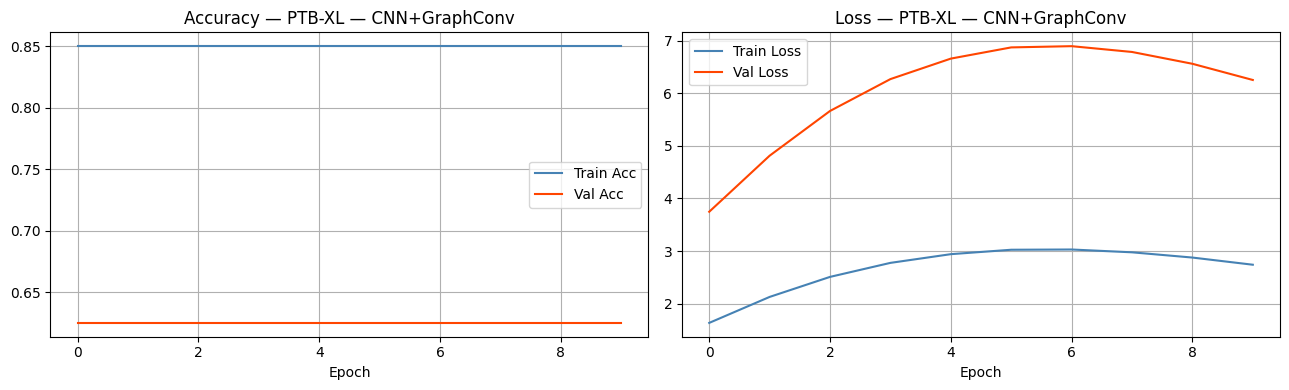

Training curves saved.
Loaded best model from: /content/drive/MyDrive/processed_data/weights/CNN_GraphConv_PTBXL_best.pth

=== Test Results — CNN+GraphConv — PTB-XL ===
              precision    recall  f1-score   support

        NORM     0.7895    1.0000    0.8824        15
          MI     0.0000    0.0000    0.0000         1
        STTC     0.0000    0.0000    0.0000         1
          CD     0.0000    0.0000    0.0000         1
         HYP     0.0000    0.0000    0.0000         1

    accuracy                         0.7895        19
   macro avg     0.1579    0.2000    0.1765        19
weighted avg     0.6233    0.7895    0.6966        19



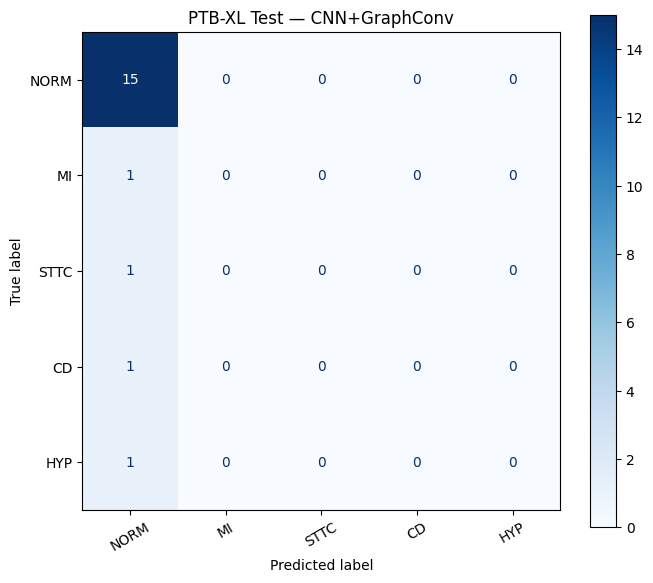

=== PTB-XL pipeline complete ===


In [31]:
%matplotlib inline

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_accs, c='steelblue', label='Train Acc')
axes[0].plot(val_accs,   c='orangered', label='Val Acc')
axes[0].set_title(f'Accuracy — PTB-XL — CNN+{LAYER_NAME}')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(train_losses, c='steelblue', label='Train Loss')
axes[1].plot(val_losses,   c='orangered', label='Val Loss')
axes[1].set_title(f'Loss — PTB-XL — CNN+{LAYER_NAME}')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(osp.join(DATA_ROOT, 'results',
            f'curves_CNN_{LAYER_NAME}_PTBXL.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved.')

# ── Load best checkpoint ──────────────────────────────────────────────────────
ckpt_path = osp.join(DATA_ROOT, 'weights', f'CNN_{LAYER_NAME}_PTBXL_best.pth')
model.load_state_dict(torch.load(ckpt_path, weights_only=False))
print(f'Loaded best model from: {ckpt_path}')

# ── Test set inference ────────────────────────────────────────────────────────
@torch.no_grad()
def inference(loader, split_label='Test'):
    model.eval()
    y_pred, y_true = [], []
    for data in loader:
        data = data.to(device)
        pred = model(data.x, data.edge_index, data.batch).argmax(dim=1)
        y_true.extend(data.y.cpu().numpy().tolist())
        y_pred.extend(pred.cpu().numpy().tolist())

    class_names = [revert_labels[str(i)] for i in range(num_classes)]
    print(f'\n=== {split_label} Results — CNN+{LAYER_NAME} — PTB-XL ===')
    print(classification_report(y_true, y_pred,
                                 labels=list(range(num_classes)),
                                 target_names=class_names,
                                 digits=4, zero_division=0))

    # cm must be defined BEFORE ConfusionMatrixDisplay uses it
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap='Blues', xticks_rotation=30, values_format='d')
    ax.set_title(f'PTB-XL {split_label} — CNN+{LAYER_NAME}')
    plt.tight_layout()
    plt.savefig(osp.join(DATA_ROOT, 'results',
                f'cm_CNN_{LAYER_NAME}_PTBXL_{split_label.lower()}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    return y_true, y_pred


y_true_ptbxl, y_pred_ptbxl = inference(test_loader, 'Test')
print('=== PTB-XL pipeline complete ===')
